# 1. Initializations

## 1.1 General imports

In [17]:
### global
import logging
import joblib
from smartcheck.logger_config import setup_logger
setup_logger(logging.INFO)
import pprint 

### data management
import pandas as pd
import numpy as np

### machine learning (scikit-learn)
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import adfuller

### graphical
import matplotlib.pyplot as plt 
# for jupyter notebook management
%matplotlib inline


## 1.2 Common imports

In [18]:
import smartcheck.dataframe_common as dfc

## 1.3 Project Specific imports

In [19]:
import smartcheck.dataframe_project_specific as dfps
import smartcheck.preprocessing_project_specific as pps
import smartcheck.modeling_project_specific as mps

# 2. Loading and Preprocessing

In [20]:
df_cpt_raw = dfc.load_dataset_from_config('velo_comptage_ml_ready_data', sep=',', index_col=0)

if df_cpt_raw is not None and isinstance(df_cpt_raw, pd.DataFrame):
    df_cpt = df_cpt_raw.copy()

[INFO]-[2025-07-16 16:43:34,880] [smartcheck.dataframe_common] File path resolved from configuration : https://drive.google.com/file/d/1elLeEL-z4hCZZ4L4gkvFKoEUMlrwxl6w/view?usp=sharing.
[INFO]-[2025-07-16 16:43:34,896] [smartcheck.dataframe_common] File ID extracted from URL: 1elLeEL-z4hCZZ4L4gkvFKoEUMlrwxl6w
[INFO]-[2025-07-16 16:43:35,515] [smartcheck.dataframe_common] Big file mechanism : Attempting download from confirmation URL.


In [21]:
df_cpt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 942554 entries, 0 to 942553
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   nom_du_site_de_comptage         942554 non-null  object 
 1   comptage_horaire                942554 non-null  int64  
 2   date_et_heure_de_comptage       942554 non-null  object 
 3   orientation_compteur            942554 non-null  object 
 4   latitude                        942554 non-null  float64
 5   longitude                       942554 non-null  float64
 6   arrondissement                  942554 non-null  object 
 7   jour_ferie                      942554 non-null  int64  
 8   vacances_scolaires              942554 non-null  object 
 9   temperature_2m_c                942554 non-null  float64
 10  weather_code_wmo_code           942554 non-null  int64  
 11  rain_mm                         942554 non-null  float64
 12  snowfall_cm          

## 2.1 Preprocessing pipelines

In [22]:
keep_cols = [
    "nom_du_site_de_comptage",
    "comptage_horaire",
    "date_et_heure_de_comptage",
    "orientation_compteur",
    # "latitude",
    # "longitude",
    # "arrondissement",
    "jour_ferie",
    "vacances_scolaires",
    "temperature_2m_c",
    "rain_mm",
    "snowfall_cm",
    # "weather_code_wmo_code",
    # "elevation",
    "weather_code_wmo_code_category",
]

pipe_preproc = Pipeline([
    ("filter_columns", pps.ColumnFilterTransformer(columns_to_keep=keep_cols)),
    ("add_datetime_features", pps.DatetimePreprocessingTransformer(timestamp_col="date_et_heure_de_comptage", for_sarimax=True)),
])

df_preproc = pipe_preproc.fit_transform(df_cpt)
if df_preproc is not None and isinstance(df_preproc, pd.DataFrame):
    df = df_preproc.copy()

In [23]:
# Verification des distributions après preprocessing
df.info()
display(df.select_dtypes(include=np.number).describe())
display(df.select_dtypes(include='object').describe())

<class 'pandas.core.frame.DataFrame'>
Index: 942554 entries, 0 to 942553
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype                       
---  ------                           --------------   -----                       
 0   nom_du_site_de_comptage          942554 non-null  object                      
 1   comptage_horaire                 942554 non-null  int64                       
 2   orientation_compteur             942554 non-null  object                      
 3   jour_ferie                       942554 non-null  int64                       
 4   vacances_scolaires               942554 non-null  object                      
 5   temperature_2m_c                 942554 non-null  float64                     
 6   rain_mm                          942554 non-null  float64                     
 7   snowfall_cm                      942554 non-null  float64                     
 8   weather_code_wmo_code_category   942554 non-null 

,comptage_horaire,jour_ferie,temperature_2m_c,rain_mm,snowfall_cm
count,942554.000000,942554.000000,942554.000000,942554.000000,942554.000000
mean,77.876087,0.026753,12.575794,0.099994,0.000823
std,106.884406,0.161360,6.674967,0.671425,0.025361
min,0.000000,0.000000,-4.600000,0.000000,0.000000
25%,11.000000,0.000000,7.800000,0.000000,0.000000
50%,42.000000,0.000000,12.400000,0.000000,0.000000
75%,97.000000,0.000000,17.000000,0.000000,0.000000
max,1574.000000,1.000000,37.200000,46.500000,1.260000


,nom_du_site_de_comptage,orientation_compteur,vacances_scolaires,weather_code_wmo_code_category
count,942554,942554,942554,942554
unique,66,8,7,7
top,27 quai de la Tournelle,NE-SO,aucune,cloud_variation
freq,19670,157136,630187,756884


## 2.2 Column Transformers

#### Categorical and Numerical

In [24]:
num_col = list(df.drop(columns='comptage_horaire').select_dtypes(include=np.number).columns)
cat_col = list(df.select_dtypes(include='object').columns)
# s_scaler = StandardScaler()
mm_scaler = MinMaxScaler()
ohe_enc = OneHotEncoder(
    # drop='first', # évites la multicolinéarité mais déclenche des warning (les catégories inconnues participent a renforcer la catégorie droppée...)
    handle_unknown='ignore'
)
tr_num_col = Pipeline(
    steps = [
        ('standardisation', mm_scaler)
    ]
)
tr_cat_col = Pipeline(
    steps = [
        ('encoder', ohe_enc)
    ]
)
tr_columns = ColumnTransformer(
    transformers=[ 
        ('num_col_transf', tr_num_col, num_col),
        ('cat_col_transf', tr_cat_col, cat_col)
    ],
    remainder='drop',
)

#### Test de la pipeline column transformer

In [25]:
pipe_columns = Pipeline(
    steps= [
        ('prep', tr_columns), 
    ]
)

In [26]:
# Fit la pipeline
array_tr = pipe_columns.fit_transform(df)
# Si sparse matrix, convertir en dense
if hasattr(array_tr, "toarray"):
    array_tr = array_tr.toarray()  # type: ignore
# Récupération des noms de colonnes
num_col_names = num_col  # inchangés
# Récupérer l'encodeur entraîné depuis la pipeline
ohe_encoder_fitted = (
    pipe_columns.named_steps['prep']
    .named_transformers_['cat_col_transf']  
)
# Récupérer les noms de colonnes encodées
cat_col_names = ohe_encoder_fitted.get_feature_names_out(cat_col)
# Concaténation des noms
all_feature_names = np.concatenate([num_col_names, cat_col_names])
# Création du DataFrame
df_tr = pd.DataFrame(array_tr, columns=all_feature_names, index=df.index)

# 3. SARIMAX Regression modeling

In [27]:
dict_compteurs = {
    "experiment_1": {
        "key": ('27 quai de la Tournelle','NO-SE'),
        "name": "Tournelle N-S",
        "sub_range": (1500,5000),
        "order": (3, 1, 3),
        "seasonal_order": (1, 1, 1, 24),
        "use_exo": True,
    },
    "experiment_2": {
        "key": ('27 quai de la Tournelle','SE-NO'),
        "name": "Tournelle S-N",
        "sub_range": (1500,5000),
        "order": (3, 1, 3),
        "seasonal_order": (1, 1, 1, 24),
        "use_exo": True,
    },
}
timestamp_col = "date_et_heure_de_comptage_local"
target_col = "comptage_horaire"

In [28]:
def detect_datetime_columns(df: pd.DataFrame) -> list[str]:
    return [
        col for col in df.columns
        if pd.api.types.is_datetime64_any_dtype(df[col])
    ]

In [29]:
def save_sarimax_model(experiment, model_results: dict, save_dir: str = "."):
    exp_params = model_results["exp_params"]
    order = exp_params["order"]
    exo = "exo_" if exp_params["use_exo"] else ""
    seasonal = exp_params["seasonal_order"]
    name = exp_params["name"].replace(" ", "-")
    start = exp_params["sub_range"][0]
    sub_range = exp_params["sub_range"]
    stop = sub_range[1] - 1 if len(sub_range) > 1 else "end"

    filename = (
        f"sarimax_results_{exo}"
        f"{order[0]}-{order[1]}-{order[2]}_"
        f"{seasonal[0]}-{seasonal[1]}-{seasonal[2]}-{seasonal[3]}_"
        f"{name}_{start}-{stop}.joblib"
    )
    filepath = f"{save_dir}/{filename}"
    joblib.dump(model_results, filepath)

    logging.info(f"{experiment} saved in {filepath}")

| Composante | Type                        | Doit être évaluée sur…                                 | Méthode                             | Où regarder                                    |
| ---------- | --------------------------- | ------------------------------------------------------ | ----------------------------------- | ---------------------------------------------- |
| **p**      | AR                          | Série **stationnaire** (différenciée si besoin)        | **PACF**                            | Les premiers lags (1, 2, 3...)                 |
| **q**      | MA                          | Série **stationnaire** (différenciée si besoin)        | **ACF**                             | Les premiers lags (1, 2, 3...)                 |
| **P**      | AR saisonnier               | Série **différenciée saisonnièrement**                 | **PACF**                            | Les **multiples** de la saison (ex. 24, 48...) |
| **Q**      | MA saisonnier               | Série **différenciée saisonnièrement**                 | **ACF**                             | Les **multiples** de la saison (ex. 24, 48...) |
| **d**      | Différenciation simple      | déterminée par test de **stationnarité**               | (ADF, KPSS, ou inspection visuelle) | —                                              |
| **D**      | Différenciation saisonnière | idem, sur tendance **saisonnière**                     | (souvent une saison de 24 ou 12)    | —                                              |
| **s**      | Période de saison           | définie à l’avance (ex. 24 pour données horaires/jour) | —                                   | —                                              |


In [30]:
def affichage_pacf_acf(y_input, exp_params):
    def ajouter_lignes_saisonnieres(ax, seasonal_lags):
        for lag in seasonal_lags:
            ax.axvline(x=lag, color='red', linestyle='--', alpha=0.6)

    # Saison estimée via dictionnaire externe
    s1 = exp_params["seasonal_order"][3]

    # Décomposition saisonnière
    decomp_res = seasonal_decompose(y_input, model='additive', period=s1)
    fig1 = decomp_res.plot()
    fig1.set_figwidth(12)
    fig1.set_figheight(12)
    fig1.suptitle("Décomposition saisonnière additive", fontsize=16)
    plt.show()

    # Test ADF : stationnarité de la série d'origine
    adf_result = adfuller(y_input)
    logging.info(f"p-value ADF sans différenciation : {adf_result[1]:.4f}")

    # Différenciation simple si non stationnaire (p > 0.01)
    if adf_result[1] > 0.01:
        y = y_input.diff(1).dropna()
        adf_result_d1 = adfuller(y)
        logging.info(f"p-value ADF après différenciation simple : {adf_result_d1[1]:.4f}")
    else:
        y = y_input

    # Différenciation saisonnière (degré 1)
    y_s1 = y.diff(s1).dropna()

    max_lag = s1 * 7  # ex: pour 7 jours de saison horaire
    seasonal_lags = [k * s1 for k in range(1, (max_lag // s1) + 1)]

    fig2, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 20))

    # PACF / ACF sur série stationnaire (détermination p, q)
    plot_pacf(y, lags=max_lag, ax=ax1)
    ax1.set_title('PACF sur série stationnaire (pour déterminer p)')
    
    plot_acf(y, lags=max_lag, ax=ax2)
    ax2.set_title('ACF sur série stationnaire (pour déterminer q)')

    # PACF / ACF sur série avec différenciation saisonnière (P, Q)
    plot_pacf(y_s1, lags=max_lag, ax=ax3)
    ajouter_lignes_saisonnieres(ax3, seasonal_lags)
    ax3.set_title(f'PACF avec différenciation saisonnière ({s1} lags) (pour déterminer P)')

    plot_acf(y_s1, lags=max_lag, ax=ax4)
    ajouter_lignes_saisonnieres(ax4, seasonal_lags)
    ax4.set_title(f'ACF avec différenciation saisonnière ({s1} lags) (pour déterminer Q)')

    plt.tight_layout()
    plt.show()

[INFO]-[2025-07-16 16:44:32,314] [root] 
--- experiment_1 : {'key': ('27 quai de la Tournelle', 'NO-SE'), 'name': 'Tournelle N-S', 'sub_range': (1500, 5000), 'order': (3, 1, 3), 'seasonal_order': (1, 1, 1, 24), 'use_exo': True} ---
[INFO]-[2025-07-16 16:44:32,330] [root] ACF et PACF


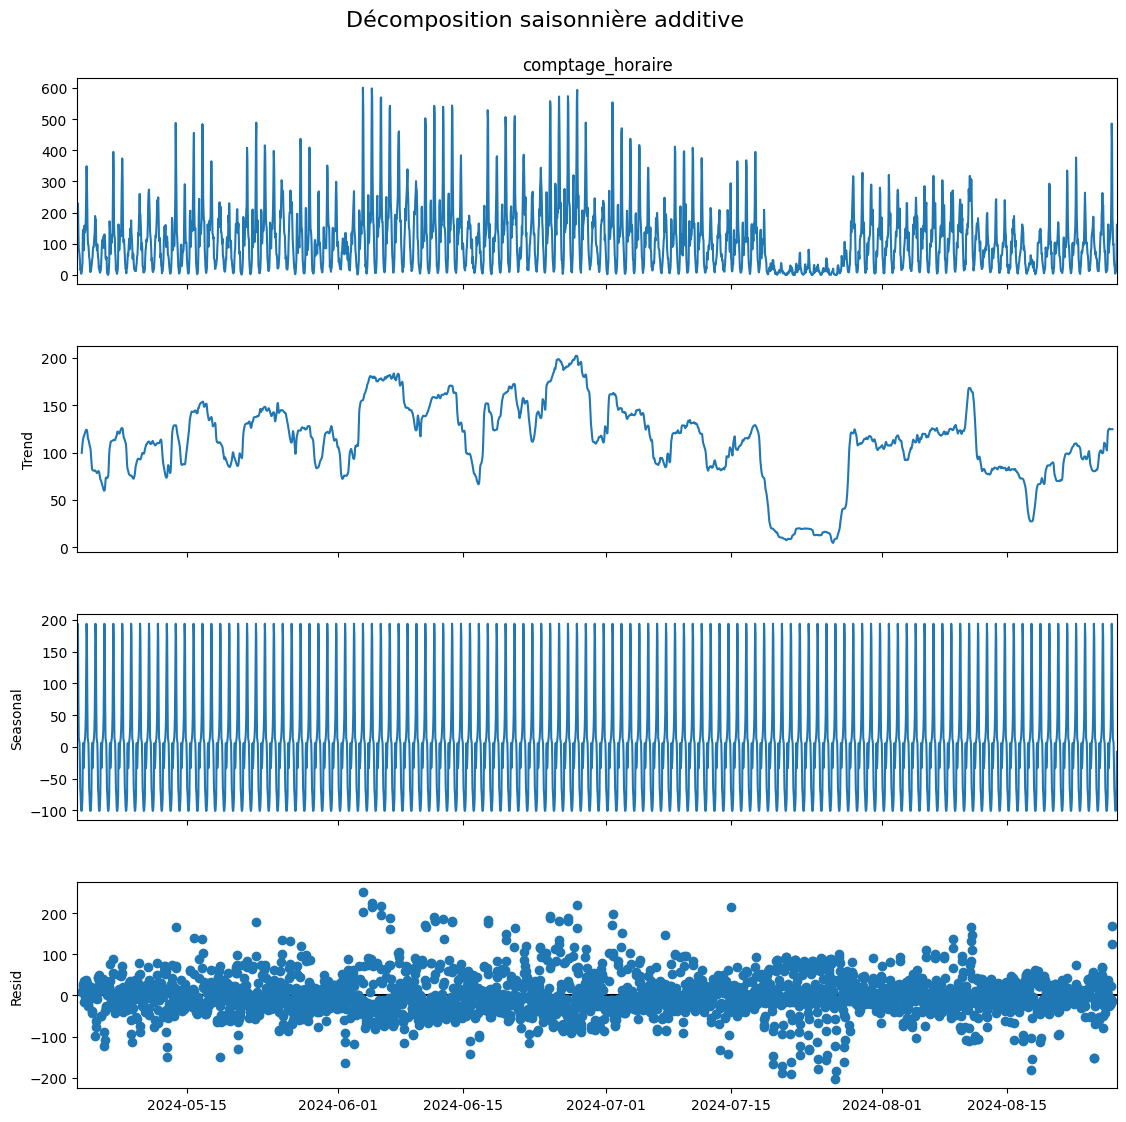

[INFO]-[2025-07-16 16:44:34,457] [root] p-value ADF sans différenciation : 0.0256
[INFO]-[2025-07-16 16:44:34,697] [root] p-value ADF après différenciation simple : 0.0000


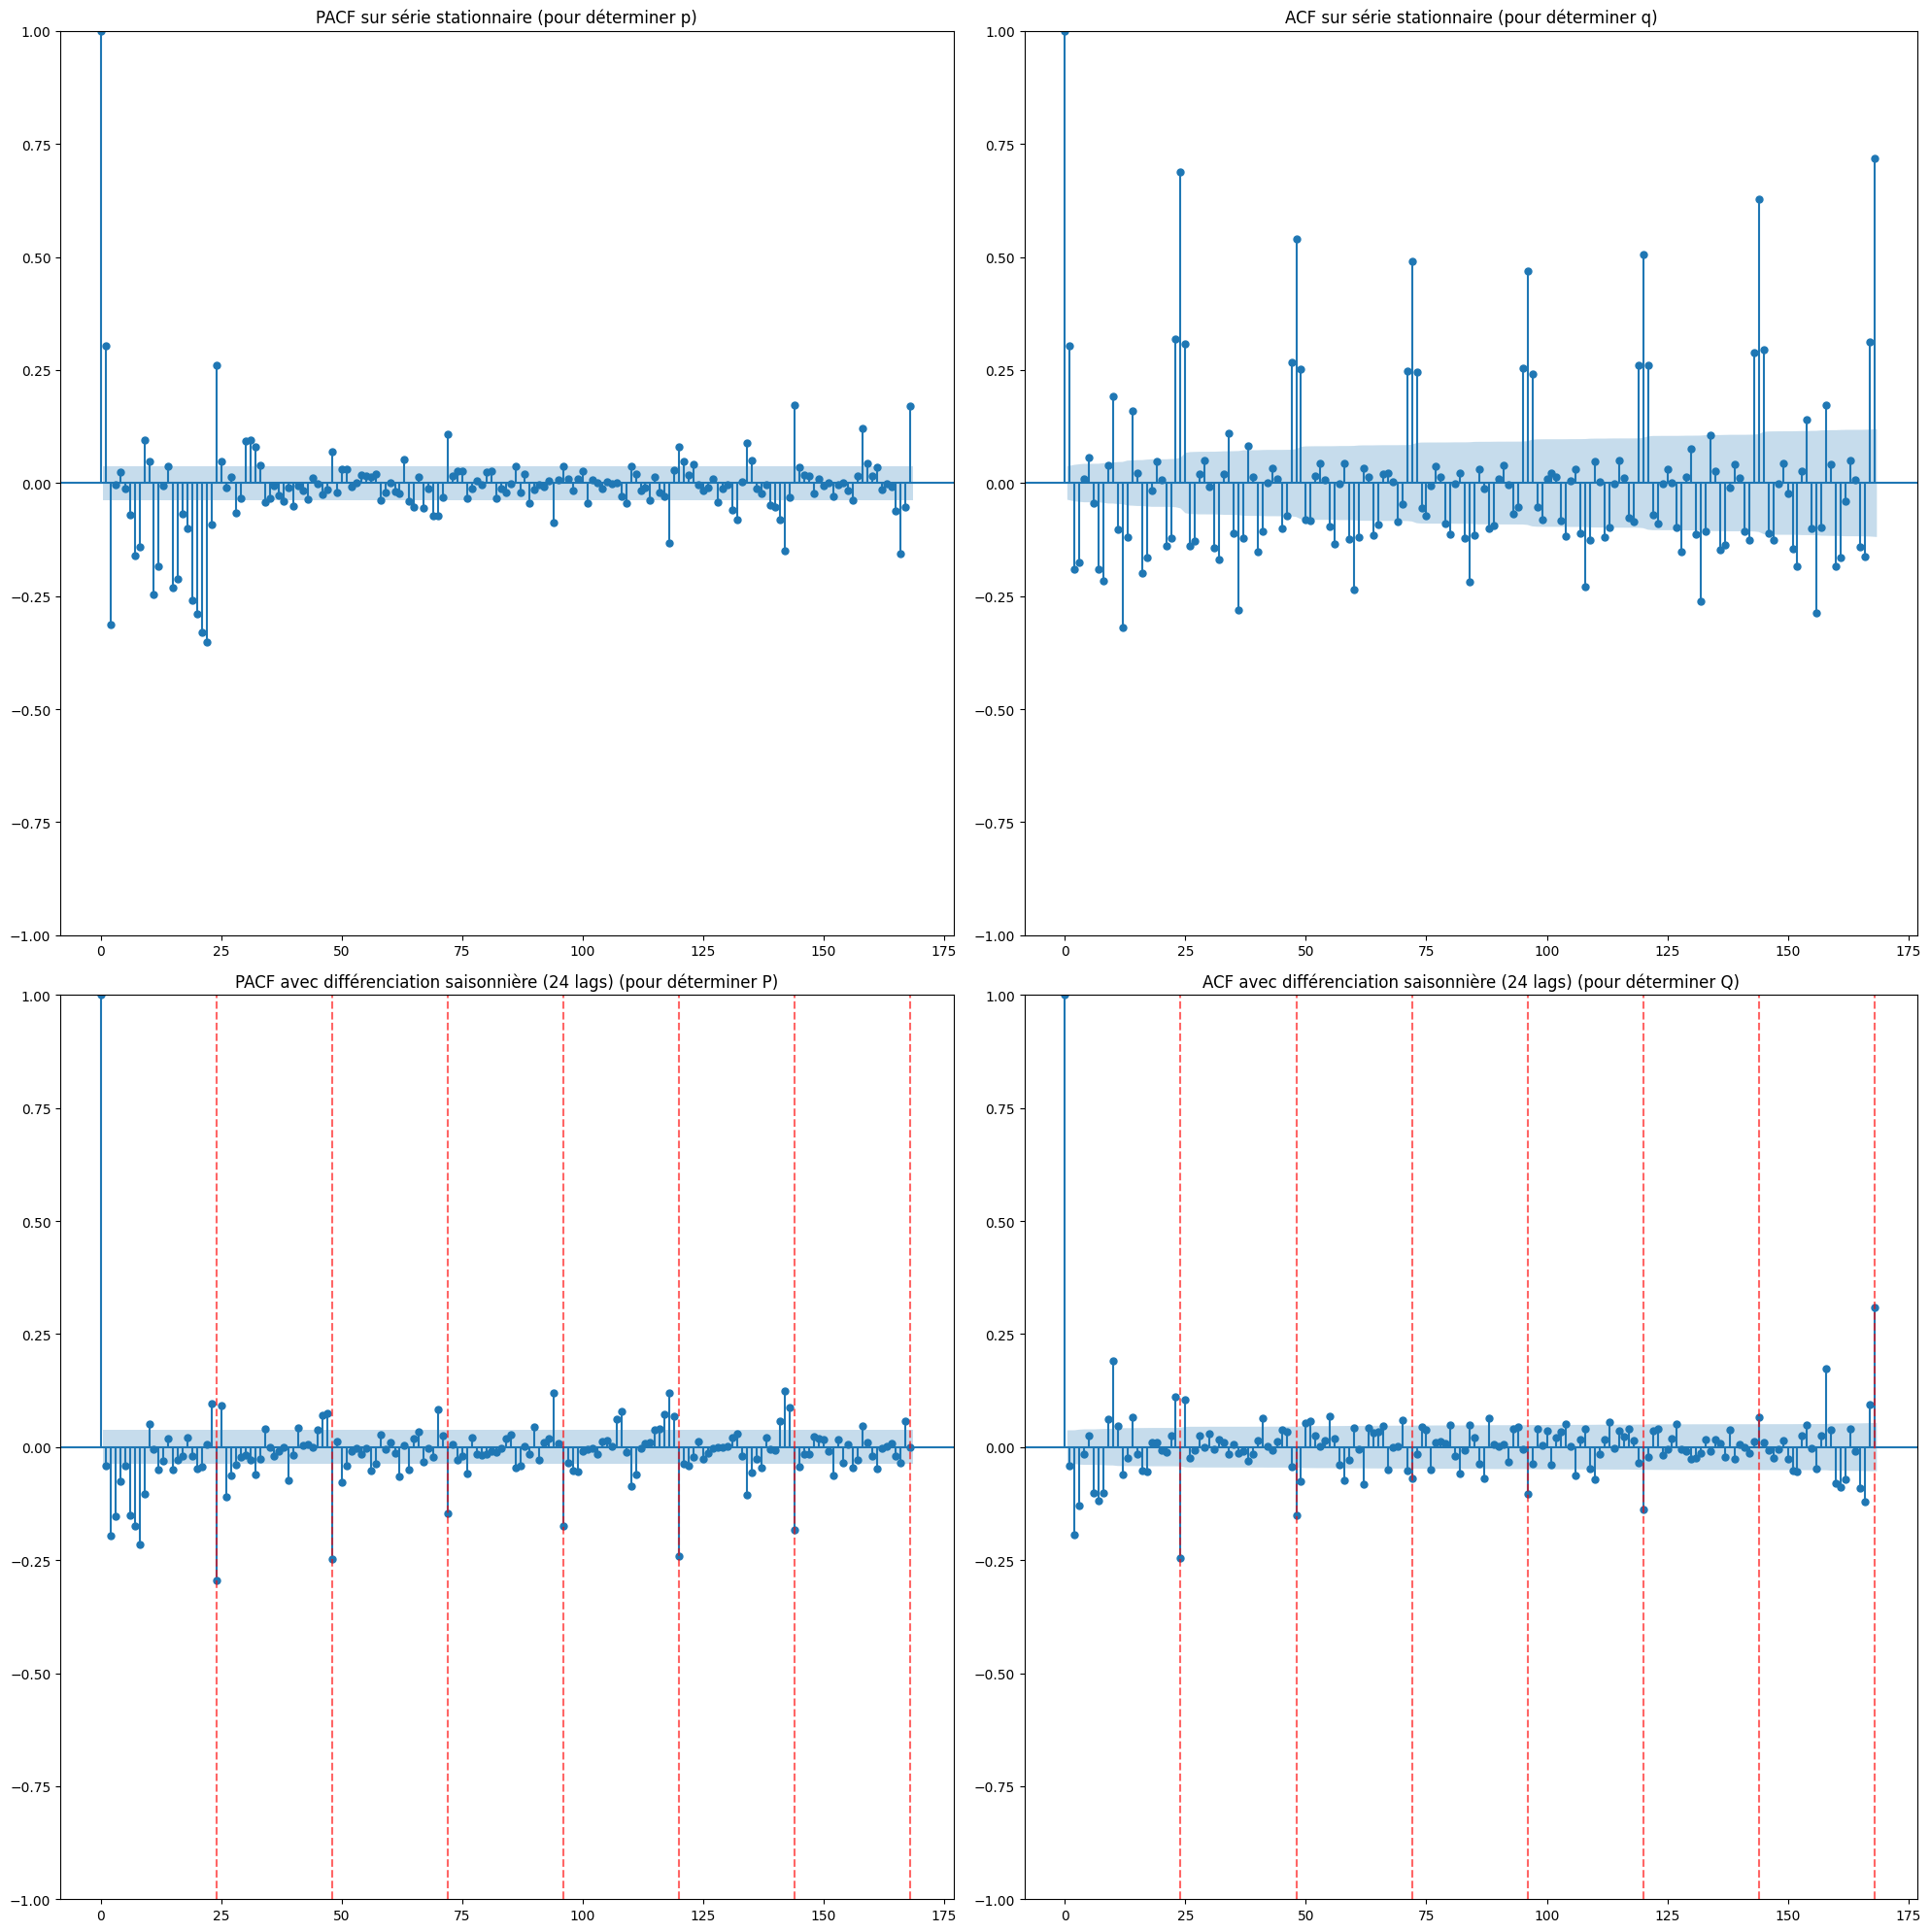

[INFO]-[2025-07-16 16:44:37,260] [root] Entraînement du modèle
[INFO]-[2025-07-16 16:44:37,284] [smartcheck.modeling_project_specific] Fitting SARIMAX model.


c:\Users\elias\Downloads\mai25-bds-trafic-cycliste-1\.nox\build-3-12\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[INFO]-[2025-07-16 16:57:11,487] [smartcheck.modeling_project_specific] SARIMAX model fitted successfully.
[INFO]-[2025-07-16 16:57:11,491] [root] Calcul des prédiction train et test pour le modèle
[INFO]-[2025-07-16 16:57:11,493] [smartcheck.modeling_project_specific] Returning in-sample fitted values.
[INFO]-[2025-07-16 16:57:11,538] [smartcheck.modeling_project_specific] Predicting future values (out-of-sample).
[INFO]-[2025-07-16 16:57:15,788] [root] experiment_1 saved in ./sarimax_results_exo_3-1-3_1-1-1-24_Tournelle-N-S_1500-4999.joblib
[INFO]-[2025-07-16 16:57:15,802] [root] 
--- experiment_2 : {'key': ('27 quai de la Tournelle', 'SE-NO'), 'name': 'Tournelle S-N', 'sub_range': (1500, 5000), 'order': (3, 1, 3), 'seasonal_order': (1, 1, 1, 24), 'use_exo': True} ---
[INFO]-[2025-07-16 16:57:15,815] [root] ACF et PACF


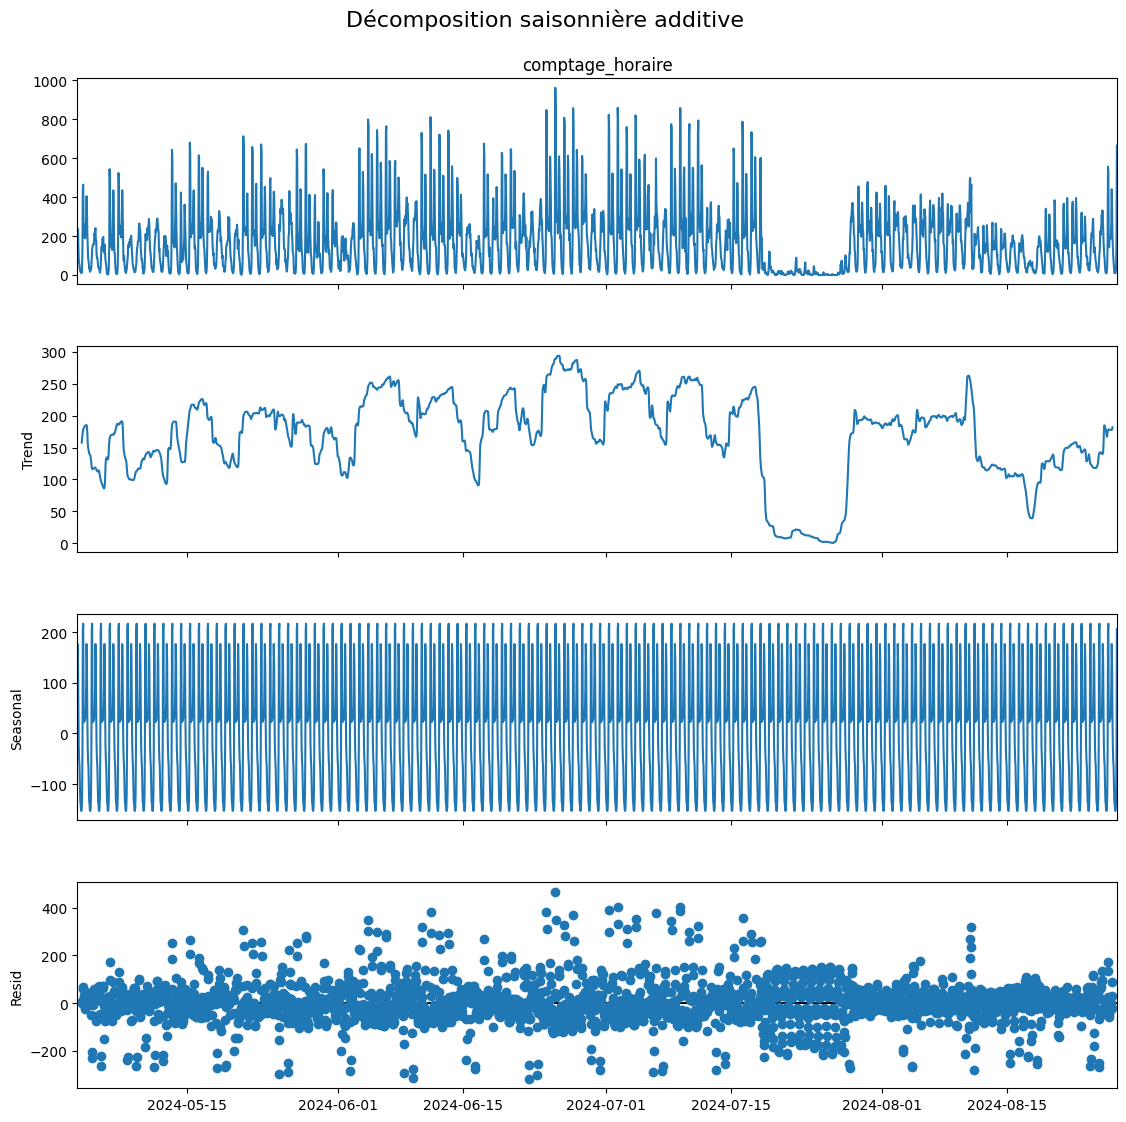

[INFO]-[2025-07-16 16:57:17,538] [root] p-value ADF sans différenciation : 0.0269
[INFO]-[2025-07-16 16:57:17,715] [root] p-value ADF après différenciation simple : 0.0000


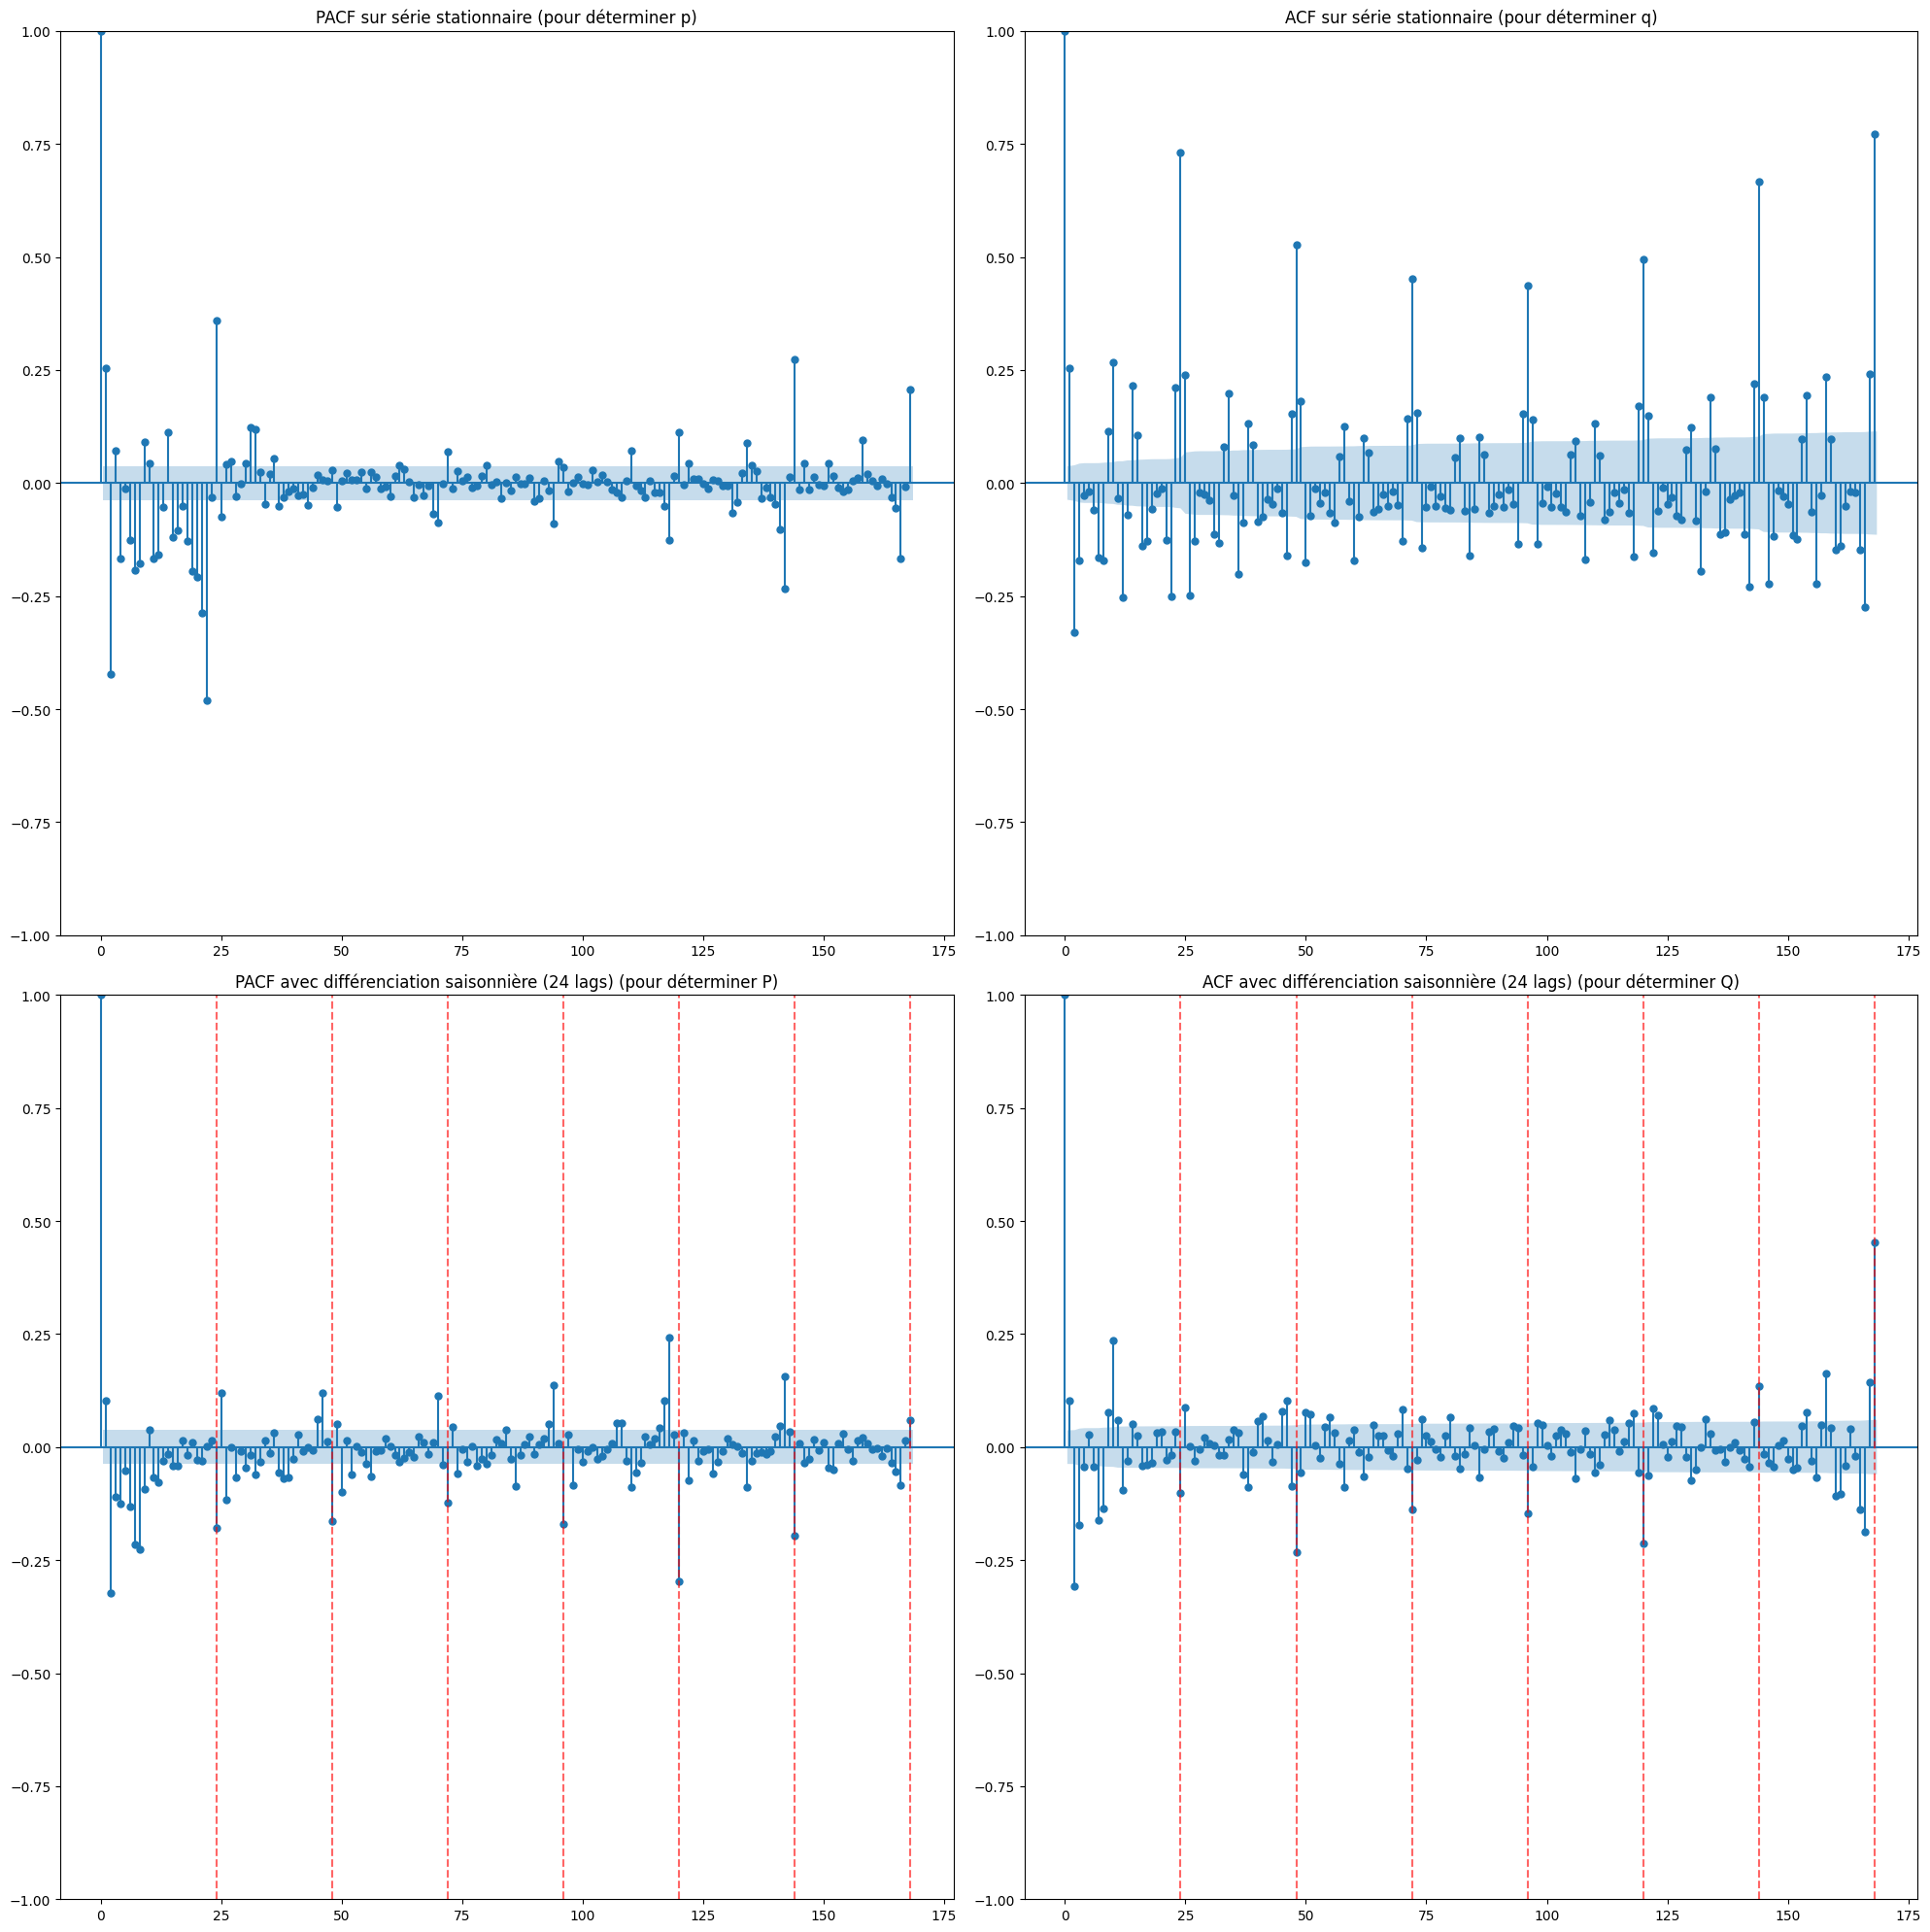

[INFO]-[2025-07-16 16:57:19,965] [root] Entraînement du modèle
[INFO]-[2025-07-16 16:57:20,025] [smartcheck.modeling_project_specific] Fitting SARIMAX model.


c:\Users\elias\Downloads\mai25-bds-trafic-cycliste-1\.nox\build-3-12\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[INFO]-[2025-07-16 17:17:50,399] [smartcheck.modeling_project_specific] SARIMAX model fitted successfully.
[INFO]-[2025-07-16 17:17:50,404] [root] Calcul des prédiction train et test pour le modèle
[INFO]-[2025-07-16 17:17:50,404] [smartcheck.modeling_project_specific] Returning in-sample fitted values.
[INFO]-[2025-07-16 17:17:50,446] [smartcheck.modeling_project_specific] Predicting future values (out-of-sample).
[INFO]-[2025-07-16 17:17:54,708] [root] experiment_2 saved in ./sarimax_results_exo_3-1-3_1-1-1-24_Tournelle-S-N_1500-4999.joblib


In [31]:
models_sarimax_results = {}
# pas d'aggrégation, juste un regroupement par nom de site et orientation (utilisé ensuite dans la boucle for)
grouped = df.groupby(["nom_du_site_de_comptage", "orientation_compteur"])
for experiment, exp_params in dict_compteurs.items():
    key = exp_params["key"]
    if key in grouped.groups:
        df_compteur = grouped.get_group(key)
        logging.info(f"\n--- {experiment} : {exp_params} ---")
    else:
        logging.info(f"⚠️ Clé {key} non trouvée dans les groupes de df.")
        continue
        
    # tri chrono + pipeline prétraitement + split
    df_compteur = df_compteur.sort_values(by=timestamp_col)
    sub_range = exp_params["sub_range"]
    range_start = sub_range[0]
    range_end = sub_range[1] if len(sub_range) > 1 else None
    df_compteur_sub = df_compteur[range_start:range_end]
    X_train, X_test, y_train, y_test, dict_missing_range = \
        dfps.train_test_split_time_aware_sarimax(
            df_compteur_sub,
            timestamp_col=timestamp_col,
            target_col=target_col,
            test_size=0.2,
            freq='h'
        )
    # verification de la continuité des index pour le sous dataframe et la fréquence choisis
    if isinstance(dict_missing_range, dict) and dict_missing_range:
        logging.info(f"⚠️ Missing data for several range\n: {pprint.pformat(dict_missing_range)}")
        continue

    logging.info("ACF et PACF")
    affichage_pacf_acf(y_train, exp_params)

    # pipeline + fit
    order = exp_params["order"]
    seasonal_order = exp_params["seasonal_order"]
    use_exo = exp_params["use_exo"]
    pipe_sarimax = Pipeline(
        steps= [
            ('prep', tr_columns), 
            ('reg',mps.SARIMAXWrapper(order=order, seasonal_order=seasonal_order, use_exo=use_exo))
        ]
    )
    logging.info("Entraînement du modèle")
    pipe_sarimax.fit(X_train, y_train)

    # predictions
    logging.info("Calcul des prédiction train et test pour le modèle")
    y_train_pred = pipe_sarimax.named_steps["reg"].predict_in_sample()
    y_test_pred = pipe_sarimax.predict(X_test)

    # stockage des resultats en mémoire
    models_sarimax_results[experiment] = {
        "exp_params":exp_params,
        "pipe":pipe_sarimax,
        "X_train":X_train,
        "X_train_dates":X_train.reset_index()[detect_datetime_columns(X_train.reset_index())],
        "X_test":X_test,
        "X_test_dates":X_test.reset_index()[detect_datetime_columns(X_test.reset_index())],
        "y_train":y_train,
        "y_train_pred":y_train_pred,
        "y_test":y_test,
        "y_test_pred":y_test_pred,
    }

    # sauvegarde de l'experimentation sur le disque
    save_sarimax_model(experiment, models_sarimax_results[experiment])

# 4 Performance analysis and visualisation

[INFO]-[2025-07-16 17:17:55,004] [root] 
********************************************************************************
Paramètres {'key': ('27 quai de la Tournelle', 'NO-SE'), 'name': 'Tournelle N-S', 'sub_range': (1500, 5000), 'order': (3, 1, 3), 'seasonal_order': (1, 1, 1, 24), 'use_exo': True} :
********************************************************************************
[INFO]-[2025-07-16 17:17:55,031] [root] Metriques du modèle (Train): {'R2': 0.8941998968668584, 'RMSE': 32.92063103634921, 'MAE': 22.09214644662726}
[INFO]-[2025-07-16 17:17:55,035] [root] Metriques du modèle (Test):: {'R2': 0.5955995932486353, 'RMSE': 73.71667527176041, 'MAE': 57.955022124554}


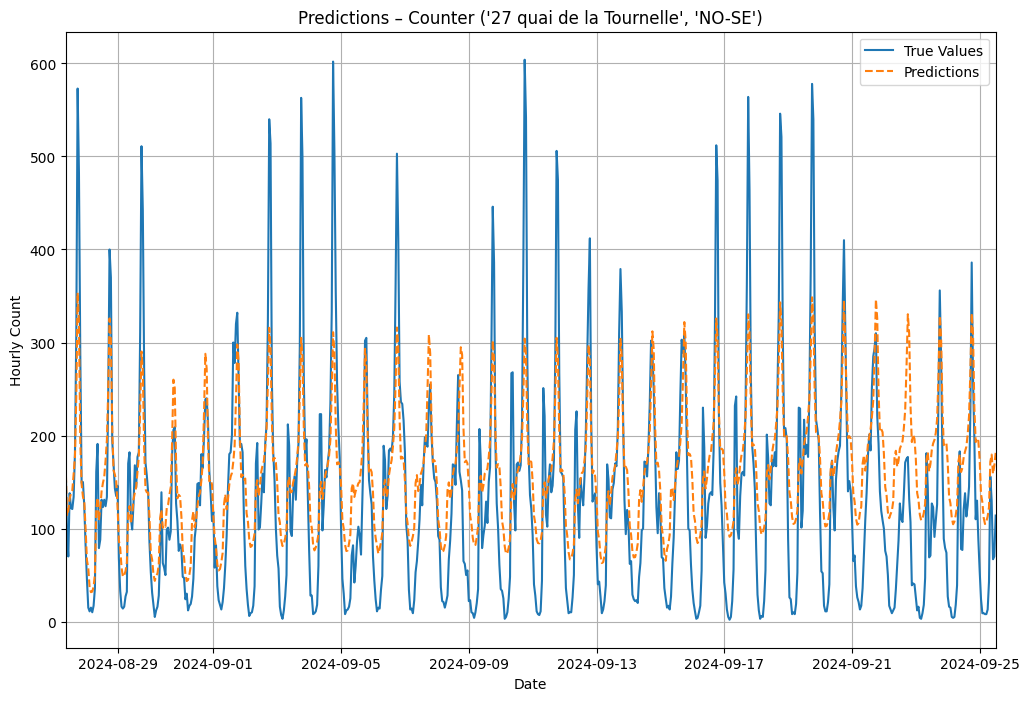

[INFO]-[2025-07-16 17:17:56,165] [root] Pente de la droite de régression des résidus dans le temps (dérive) : -2.2602868144331416


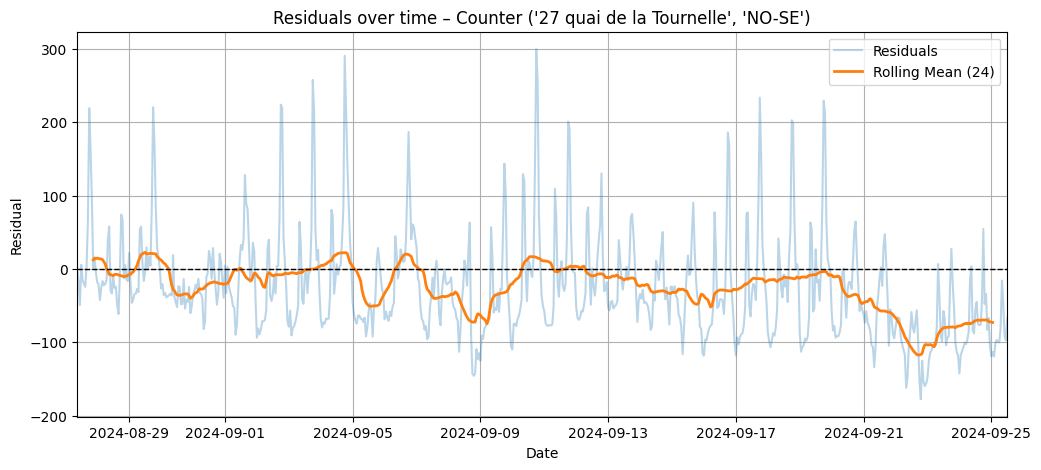

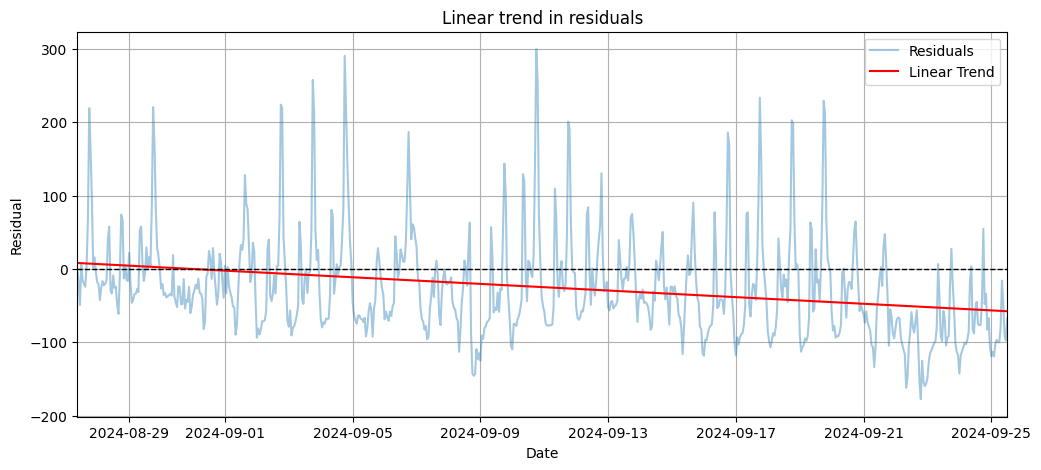

[INFO]-[2025-07-16 17:17:57,313] [root] 
********************************************************************************
Paramètres {'key': ('27 quai de la Tournelle', 'SE-NO'), 'name': 'Tournelle S-N', 'sub_range': (1500, 5000), 'order': (3, 1, 3), 'seasonal_order': (1, 1, 1, 24), 'use_exo': True} :
********************************************************************************
[INFO]-[2025-07-16 17:17:57,335] [root] Metriques du modèle (Train): {'R2': 0.8648969034855853, 'RMSE': 57.14081287090072, 'MAE': 36.02840579594513}
[INFO]-[2025-07-16 17:17:57,339] [root] Metriques du modèle (Test):: {'R2': 0.4514129851630114, 'RMSE': 134.17822436284544, 'MAE': 109.18297970077492}


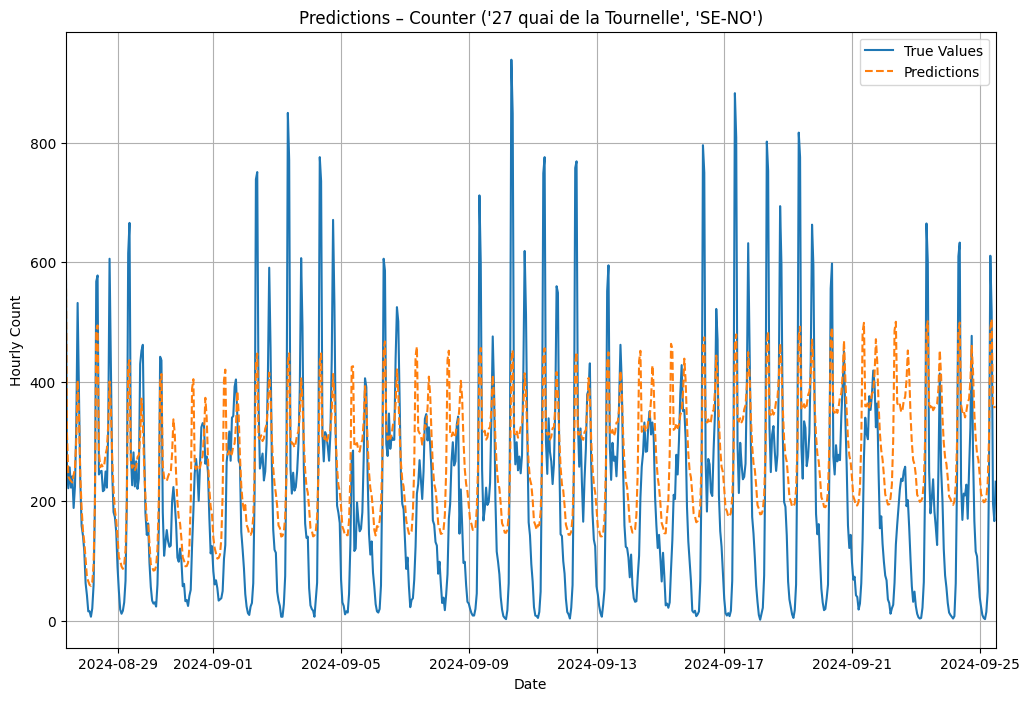

[INFO]-[2025-07-16 17:17:58,909] [root] Pente de la droite de régression des résidus dans le temps (dérive) : -3.6621097046960163


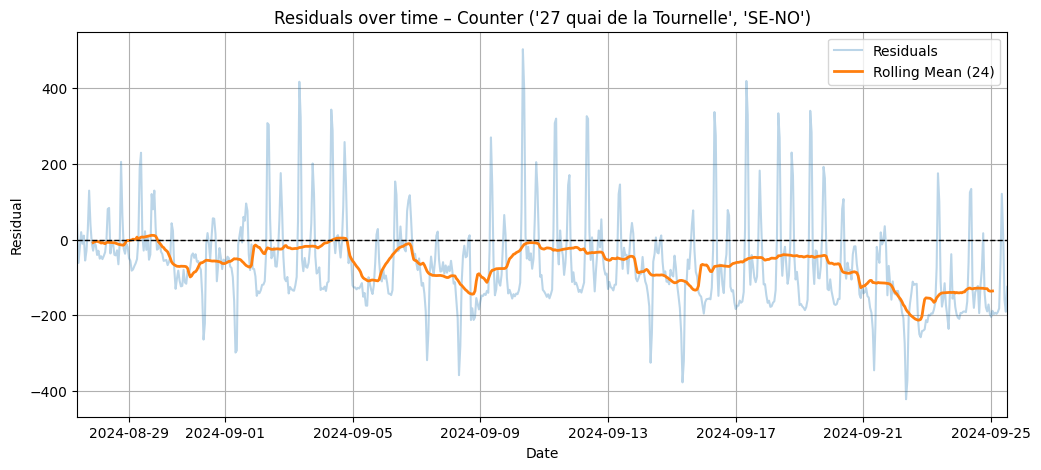

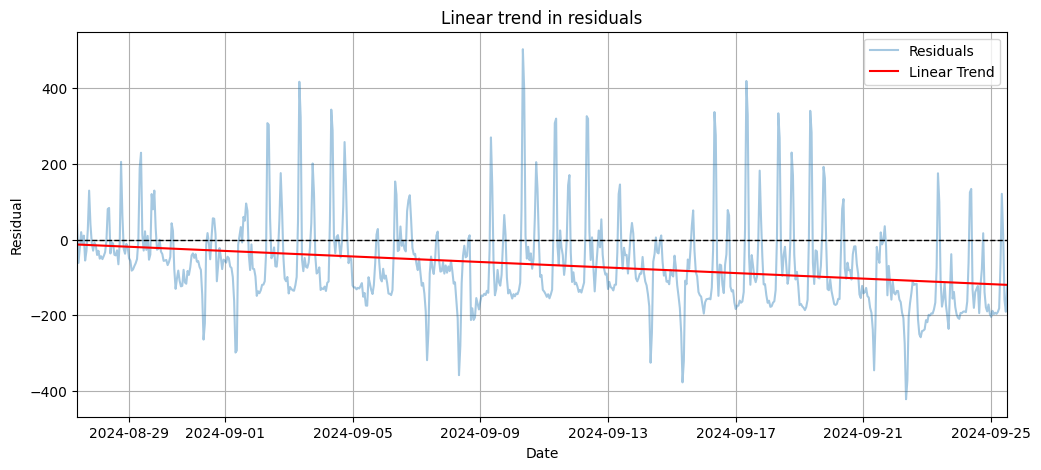

In [32]:
# Afficher une modélisation de compteur spécifique
models_results = models_sarimax_results
for experiment, model_results in models_results.items():
    exp_params = model_results["exp_params"]
    compteur_key = exp_params["key"]
    logging.info(f"\n{"*"*80}\nParamètres {exp_params} :\n{"*"*80}")
    dates = model_results["X_test_dates"]["date_et_heure_de_comptage_local"]  # type: ignore
    X_test_dates = model_results["X_test_dates"]  # type: ignore
    y_test = model_results["y_test"]  # type: ignore
    y_train = model_results["y_train"]  # type: ignore
    y_train_pred = model_results["y_train_pred"]  # type: ignore
    y_test_pred = model_results["y_test_pred"]  # type: ignore
    periode_limite = (
        dates[0],
        # dates[len(dates)-310],
        dates[len(dates)-1]
    )

    # Affichage des metrique train et test
    model_train_metrics = mps.compute_metrics(
        y_train,
        y_train_pred
    )
    model_test_metrics = mps.compute_metrics(
        y_test,
        y_test_pred
    )
    logging.info(f"Metriques du modèle (Train): {model_train_metrics}")
    logging.info(f"Metriques du modèle (Test):: {model_test_metrics}")

    # projection des predictions de test dans le temps
    fig_pred = mps.plot_predictions(
        str(compteur_key),
        X_test_dates, 
        y_test, 
        y_test_pred, 
        periode_limite=periode_limite
    )
    plt.show()

    # projection des résidus et calcul du coefficient de dérive dans le temps
    fig1_res, fig2_res, model_res_coeff = mps.compute_residuals_plot(
        str(compteur_key),
        X_test_dates, 
        y_test, 
        y_test_pred.values, 
        periode_limite=periode_limite
    )
    logging.info(f"Pente de la droite de régression des résidus dans le temps (dérive) : {model_res_coeff}")
    plt.show()